<h1>Decision Trees: Flag Classification Project</h1>

Using flag data from the UCI Machine Learning Repository I am going to build a classifcation algorithm to predict what continent a flag is from. 

The aim of this project is to simply practice techniques learned about decision trees to a real world dataset that is ready to be used. I am aware in all cases cleaning data and preparing it ready for use is a large part of creating an accurate model - however for the sake of what I am trying to demonstrate in this project it is not required to be so granular. 

Importing relevant modules

In [27]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

Importing the dataset

In [28]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
flags = fetch_ucirepo(id=40) 
  
# data (as pandas dataframes) 
df = flags.data.features 

print(df)
# variable information 
print(flags.variables) 

               name  landmass  zone  area  population  language  religion  \
0       Afghanistan         5     1   648          16        10         2   
1           Albania         3     1    29           3         6         6   
2           Algeria         4     1  2388          20         8         2   
3    American-Samoa         6     3     0           0         1         1   
4           Andorra         3     1     0           0         6         0   
..              ...       ...   ...   ...         ...       ...       ...   
189   Western-Samoa         6     3     3           0         1         1   
190      Yugoslavia         3     1   256          22         6         6   
191           Zaire         4     2   905          28        10         5   
192          Zambia         4     2   753           6        10         5   
193        Zimbabwe         4     2   391           8        10         5   

     bars  stripes  colours  ...  saltries  quarters  sunstars  crescent  \

I am aware there are no missing data points in this so there is no need to deal with missing/null values. The target variable in this case is continent, indicated by <code>landmass</code>:  1=N.America, 2=S.America, 3=Europe, 4=Africa, 5=Asia, 6=Oceania. 

In [29]:
cols = df.columns
print(cols)

Index(['name', 'landmass', 'zone', 'area', 'population', 'language',
       'religion', 'bars', 'stripes', 'colours', 'red', 'green', 'blue',
       'gold', 'white', 'black', 'orange', 'mainhue', 'circles', 'crosses',
       'saltries', 'quarters', 'sunstars', 'crescent', 'triangle', 'icon',
       'animate', 'text', 'topleft', 'botright'],
      dtype='object')


In [30]:
predictor_variables = ['bars', 'stripes', 'colours', 'red', 'green', 'blue',
       'gold', 'white', 'black', 'orange', 'mainhue', 'circles', 'crosses',
       'saltries', 'quarters', 'sunstars', 'crescent', 'triangle', 'icon',
       'animate']

In [31]:
target_variable = 'landmass'

Dataset inspection of the predictor variables

In [32]:
print(df[predictor_variables].dtypes)

bars         int64
stripes      int64
colours      int64
red          int64
green        int64
blue         int64
gold         int64
white        int64
black        int64
orange       int64
mainhue     object
circles      int64
crosses      int64
saltries     int64
quarters     int64
sunstars     int64
crescent     int64
triangle     int64
icon         int64
animate      int64
dtype: object


In [33]:
# mainhue is a categorical variable - dummy variables need to be created for it
X = pd.get_dummies(data=df[predictor_variables], columns=['mainhue'], drop_first=False, prefix=None)
y = df[target_variable]

In [34]:
# Distribution of the means for each of the predictor variables to identify outliers and inform of normalisation required.
mean_predicitor_variables = df[predictor_variables].mean(axis=0, numeric_only=True)
print(mean_predicitor_variables)

bars        0.453608
stripes     1.551546
colours     3.463918
red         0.788660
green       0.469072
blue        0.510309
gold        0.469072
white       0.752577
black       0.268041
orange      0.134021
circles     0.170103
crosses     0.149485
saltries    0.092784
quarters    0.149485
sunstars    1.386598
crescent    0.056701
triangle    0.139175
icon        0.252577
animate     0.201031
dtype: float64


In [35]:
# Mean preditor variables grouped by the landmass (continent)
mean_pred_variables_groupedby_landmass = df.groupby('landmass')[predictor_variables].mean(numeric_only=True)
display(mean_pred_variables_groupedby_landmass)

,bars,stripes,colours,red,green,blue,gold,white,black,orange,circles,crosses,saltries,quarters,sunstars,crescent,triangle,icon,animate
landmass,,,,,,,,,,,,,,,,,,,
1,0.580645,1.451613,3.870968,0.677419,0.419355,0.774194,0.516129,0.838710,0.354839,0.193548,0.193548,0.225806,0.193548,0.193548,2.806452,0.000000,0.258065,0.290323,0.419355
2,0.352941,2.176471,3.705882,0.764706,0.411765,0.705882,0.647059,0.823529,0.235294,0.058824,0.176471,0.058824,0.058824,0.411765,2.117647,0.000000,0.117647,0.176471,0.176471
3,0.628571,1.285714,3.000000,0.828571,0.200000,0.514286,0.428571,0.771429,0.171429,0.057143,0.028571,0.285714,0.028571,0.028571,0.142857,0.000000,0.028571,0.257143,0.114286
4,0.673077,1.942308,3.519231,0.807692,0.826923,0.307692,0.519231,0.538462,0.326923,0.134615,0.115385,0.038462,0.057692,0.057692,0.576923,0.076923,0.134615,0.173077,0.134615
5,0.179487,1.666667,3.153846,0.820513,0.435897,0.333333,0.256410,0.820513,0.282051,0.179487,0.358974,0.025641,0.025641,0.102564,1.153846,0.179487,0.102564,0.333333,0.153846
6,0.000000,0.400000,3.900000,0.800000,0.200000,0.800000,0.600000,0.950000,0.150000,0.150000,0.150000,0.400000,0.300000,0.400000,3.300000,0.000000,0.250000,0.300000,0.300000


We compute the overall means of predictor variables to assess their scales and detect potential outliers.
This helps inform whether normalisation or transformation is needed, especially for algorithms sensitive to feature scales. In this case it is important to not decision trees are <bold>scale invariant</bold>. Although decision trees are scale-invariant, this analysis supports better feature understanding and may guide preprocessing for other models.

Decision trees are scale invariant because the linear separations they seek try to maximize homogeneity between classes by considering one variable at a time, so it negates the possible effect that a correlation with another variable with different scale would have. Normalisation is recomended anyway to reduce computational work for training. 

Grouping by the target variable ('landmass') allows us to observe class-specific patterns and outliers.
This highlights differences in feature distributions between continents, which can aid in understanding class separability.


For the predictor variables only:
| Feature                     | Value Range / Mean | Type            | Comment                      |
| --------------------------- | ------------------ | --------------- | ---------------------------- |
| `bars`                      | \~0.45             | Count           | Small integer counts         |
| `stripes`                   | \~1.55             | Count           | Small range                  |
| `colours`                   | \~3.46             | Count           | Slightly larger, still small |
| `sunstars`                  | \~1.39             | Count           | Similar to `stripes`         |
| `red`, `green`, etc.        | \~0.0–1.0          | Binary (0 or 1) | Already scaled               |
| `crosses`, `saltries`, etc. | \~0.1–0.2          | Binary          | No need to normalize         |

For the predictor variables grouped by landmass:
| Feature         | Range Across Continents | Comment                       |
| --------------- | ----------------------- | ----------------------------- |
| `bars`          | 0.0 to \~0.67           | Low variance, small scale     |
| `stripes`       | \~0.4 to \~2.18         | Slight variation, still small |
| `colours`       | \~3.0 to \~3.9          | Moderate but consistent scale |
| `sunstars`      | \~0.14 to \~3.3         | Most variable of the group    |
| Others (binary) | \~0 to \~1              | Already scaled                |

<h1>Model Implementation</h1>



In [36]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# Fitting the model 
depths = range(1, 21)
acc_depth = []
for depth in depths:
  dt = DecisionTreeClassifier(max_depth=depth)
  dt.fit(x_train, y_train)
  y_pred = dt.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  acc_depth.append(accuracy)

Maximum accuracy 0.5384615384615384, achieved at 3 depth


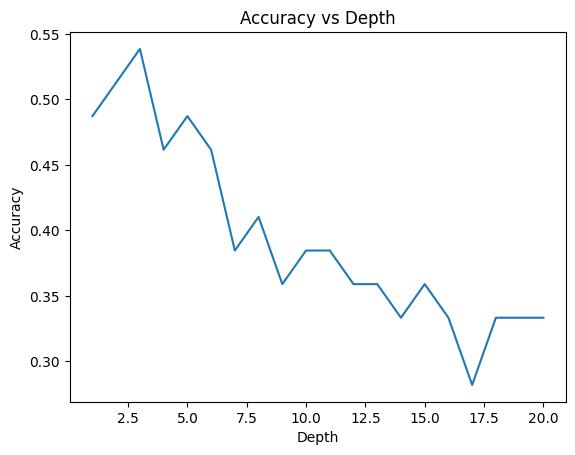

In [37]:
plt.plot(depths, acc_depth)
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Depth")

maximum_accuracy = max(acc_depth)
best_depth = depths[acc_depth.index(maximum_accuracy)]
print(f"Maximum accuracy {maximum_accuracy}, achieved at {best_depth} depth")

Refitting the model with informed depth decision. The accuracy is too low for this to be useable. Tuning the model using pruning with the aim of increasing the accuracy. <code>ccp_alpha</code> is the pruning strength parameter, higher values mean smaller trees, lower values mean bigger trees. The aim of using ccp is to reduce overfitting of the model. CCP value is data dependent so using the built in <code>cost_complexity_pruning_path</code> is a good start to find values.

In [38]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"y_pred = {y_pred}")
print(f"Accuracy = {accuracy}")

y_pred = [6 4 3 3 3 4 5 6 4 4 3 5 4 4 4 4 5 3 4 4 3 3 5 4 5 3 4 4 5 6 4 1 1 4 4 5 4
 4 4]
Accuracy = 0.5384615384615384


In [39]:
path = dt.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.01382488 0.01620584 0.01858679 0.02085494 0.03160098
 0.03663594 0.04030189]


In [40]:
ccp_accuracies = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(max_depth=3, ccp_alpha=alpha)
    dt.fit(x_train, y_train)
    y_pred = dt.predict(x_test)
    ccp_accuracy = accuracy_score(y_test, y_pred)
    ccp_accuracies.append(ccp_accuracy)


Maximum accuracy 0.5384615384615384, achieved at 0.0 CCP


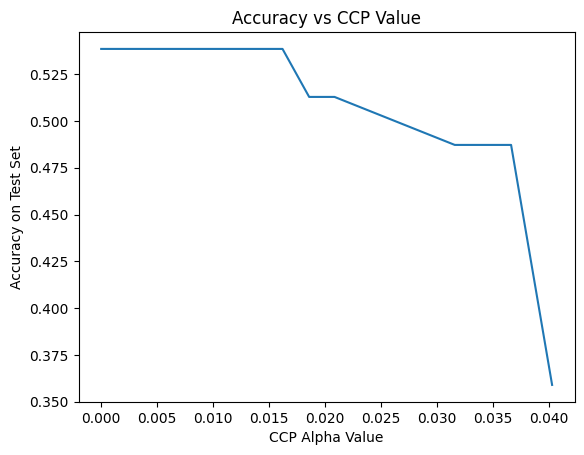

In [41]:
plt.plot(ccp_alphas, ccp_accuracies)
plt.xlabel("CCP Alpha Value")
plt.ylabel("Accuracy on Test Set")
plt.title("Accuracy vs CCP Value")

maximum_accuracy = max(ccp_accuracies)
best_alpha = ccp_alphas[ccp_accuracies.index(maximum_accuracy)]
print(f"Maximum accuracy {maximum_accuracy}, achieved at {best_alpha} CCP")

CCP seemingly had no effect likely due to the tree already being at max depth 3 so there is little to prune. Removing max_depth=3 demonstrates the effect of pruning, subsequently removed however. 

In [42]:
# Final model fitting
dt = DecisionTreeClassifier(max_depth=3, ccp_alpha=0)
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)

In [43]:
print(dt.classes_)

[1 2 3 4 5 6]


[Text(0.5, 0.875, 'green <= 0.5\ngini = 0.816\nsamples = 155\nvalue = [29, 15, 27, 38, 31, 15]\nclass = Africa'),
 Text(0.25, 0.625, 'sunstars <= 0.5\n0.81\n83\n[17, 8, 21, 7, 18, 12]\nEurope'),
 Text(0.125, 0.375, 'mainhue_blue <= 0.5\n0.753\n50\n[11, 6, 20, 4, 6, 3]\nEurope'),
 Text(0.0625, 0.125, '0.701\n37\n[4, 5, 18, 2, 6, 2]\nEurope'),
 Text(0.1875, 0.125, '0.651\n13\n[7, 1, 2, 2, 0, 1]\nN. America'),
 Text(0.375, 0.375, 'sunstars <= 3.0\n0.747\n33\n[6, 2, 1, 3, 12, 9]\nAsia'),
 Text(0.3125, 0.125, '0.712\n21\n[3, 2, 1, 3, 10, 2]\nAsia'),
 Text(0.4375, 0.125, '0.569\n12\n[3, 0, 0, 0, 2, 7]\nOceania'),
 Text(0.75, 0.625, 'colours <= 5.5\n0.736\n72\n[12, 7, 6, 31, 13, 3]\nAfrica'),
 Text(0.625, 0.375, 'white <= 0.5\n0.649\n56\n[4, 4, 5, 30, 12, 1]\nAfrica'),
 Text(0.5625, 0.125, '0.399\n21\n[2, 1, 0, 16, 2, 0]\nAfrica'),
 Text(0.6875, 0.125, '0.727\n35\n[2, 3, 5, 14, 10, 1]\nAfrica'),
 Text(0.875, 0.375, 'stripes <= 2.5\n0.688\n16\n[8, 3, 1, 1, 1, 2]\nN. America'),
 Text(0.8125, 0.

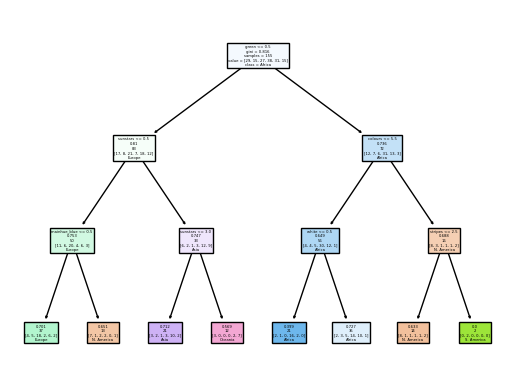

In [44]:
# Map class labels 1–6 to continent names
label_to_name = {
    1: "N. America",
    2: "S. America",
    3: "Europe",
    4: "Africa",
    5: "Asia",
    6: "Oceania"
}

# Convert dt.classes_ (e.g., [1,2,3,4,5,6]) to their string labels in order
class_names_list = [label_to_name[label] for label in dt.classes_]


tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names=class_names_list,
    max_depth = 3, 
    label='root', 
    filled=True
)
